# **Day 59: PyTorch - Tensors and Autograd**
*Module 10 - Deep Learning Foundations*

**PyTorch** is the most used deep-learning framework in research (and in geospatial AI: TorchGeo, Prithvi, SAM). It gives us: NumPy-like **tensors** that run on GPUs, and **autograd**, the automatic differentiation engine we built by hand on Day 8.

> PyTorch tensors are like NumPy arrays that can run on a GPU and remember how they were computed. Autograd then calculates all the gradients automatically, so we never derive them by hand.
>
> *Example:* Write the loss as a formula of the weights, call `loss.backward()`, and PyTorch fills in every weight's gradient.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
torch.manual_seed(59)
print("PyTorch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("using device:", device)

PyTorch 2.14.1+cpu | CUDA available: False
using device: cpu


## **1. Tensors**

In [2]:
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(a, a.dtype, a.shape)
print(torch.zeros(2, 3), torch.ones(2), torch.arange(0, 10, 3), torch.linspace(0, 1, 5))
print("random normal:", torch.randn(2, 3))
x16 = torch.randint(0, 10000, (4, 4), dtype=torch.int16)               # like Sentinel-2 digital numbers
print("int16 -> float32 reflectance:", (x16.float() / 10000)[0])

tensor([[1., 2.],
        [3., 4.]]) torch.float32 torch.Size([2, 2])
tensor([[0., 0., 0.],
        [0., 0., 0.]]) tensor([1., 1.]) tensor([0, 3, 6, 9]) tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
random normal: tensor([[-0.7782,  0.4032, -0.8727],
        [ 0.3325, -0.4457, -0.9303]])
int16 -> float32 reflectance: tensor([0.6627, 0.0199, 0.7421, 0.5102])


### Shapes in deep learning

| Data | PyTorch convention |
|---|---|
| Tabular batch | `(batch, features)` |
| Image batch | `(batch, channels, height, width)`: **NCHW** |
| Sequence batch | `(batch, time, features)` (with `batch_first=True`) |
| Satellite patch batch | `(batch, bands, H, W)`, e.g. `(32, 13, 64, 64)` for Sentinel-2 |

In [3]:
imgs = torch.randn(32, 13, 64, 64)
print("batch of 32 Sentinel-2 patches:", imgs.shape)
print("first patch, NIR band (B8 = index 7):", imgs[0, 7].shape)
print("per-band mean over batch and pixels:", imgs.mean(dim=(0, 2, 3)).shape)
print("flatten each image:", imgs.flatten(start_dim=1).shape, "| view:", imgs.view(32, -1).shape)
print("NCHW -> NHWC:", imgs.permute(0, 2, 3, 1).shape, "| add a dim:", imgs[0].unsqueeze(0).shape)

batch of 32 Sentinel-2 patches: torch.Size([32, 13, 64, 64])
first patch, NIR band (B8 = index 7): torch.Size([64, 64])
per-band mean over batch and pixels: torch.Size([13])
flatten each image: torch.Size([32, 53248]) | view: torch.Size([32, 53248])
NCHW -> NHWC: torch.Size([32, 64, 64, 13]) | add a dim: torch.Size([1, 13, 64, 64])


### NumPy interoperability and devices

In [4]:
n = np.arange(6.0).reshape(2, 3)
t = torch.from_numpy(n)                     # shares memory with the NumPy array!
n[0, 0] = 100
print("tensor sees the change:", t[0, 0].item())
back = t.numpy(); print("back to NumPy:", type(back))
t_dev = torch.randn(3, 3).to(device)        # move to GPU if available
print("tensor device:", t_dev.device, "| always move data AND model to the same device")

tensor sees the change: 100.0
back to NumPy: <class 'numpy.ndarray'>
tensor device: cpu | always move data AND model to the same device


## **2. Autograd**
Set `requires_grad=True` and PyTorch records every operation in a graph. `loss.backward()` computes $\partial\,\text{loss}/\partial w$ for every leaf tensor and stores it in `w.grad`.

In [5]:
w = torch.tensor(0.7, requires_grad=True); b = torch.tensor(-0.2, requires_grad=True)
x, y = torch.tensor(2.0), torch.tensor(1.0)
p = torch.sigmoid(w * x + b)
loss = -(y * torch.log(p) + (1 - y) * torch.log(1 - p))
loss.backward()
print(f"loss {loss.item():.6f} | dL/dw {w.grad.item():.6f} (by hand (p - y) x = {((p - y) * x).item():.6f}) | dL/db {b.grad.item():.6f}")
print("the graph:", loss.grad_fn, "<-", loss.grad_fn.next_functions[0][0])

loss 0.263282 | dL/dw -0.462950 (by hand (p - y) x = -0.462950) | dL/db -0.231475
the graph: <NegBackward0 object at 0x0000026D4E96CA30> <- <AddBackward0 object at 0x0000026D4E96C9A0>


### Three gotchas
1. **Gradients accumulate**: call `optimizer.zero_grad()` (or `w.grad = None`) before each backward pass.
2. Use `torch.no_grad()` for evaluation/inference: no graph, less memory, faster.
3. `tensor.detach()` cuts a tensor out of the graph (e.g. before converting to NumPy for plotting).

In [6]:
w2 = torch.tensor(1.0, requires_grad=True)
for i in range(3):
    (w2 * 3).backward()
    print(f"after backward #{i + 1}: grad = {w2.grad.item()}  (accumulates!)")
w2.grad = None
with torch.no_grad():
    y_eval = w2 * 3
print("inside no_grad, requires_grad =", y_eval.requires_grad)

after backward #1: grad = 3.0  (accumulates!)
after backward #2: grad = 6.0  (accumulates!)
after backward #3: grad = 9.0  (accumulates!)
inside no_grad, requires_grad = False


## **3. Linear Regression With Raw Tensors**

learned w = 2.995, b = 1.955 (true 3, 2)


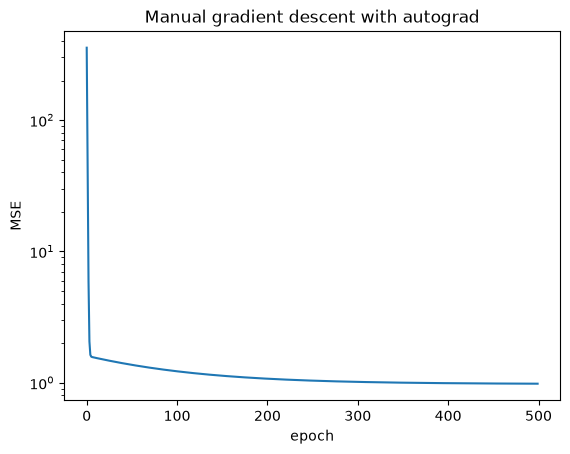

In [7]:
X = torch.rand(200, 1) * 10; y = 3.0 * X + 2.0 + torch.randn(200, 1)
w = torch.zeros(1, 1, requires_grad=True); b = torch.zeros(1, requires_grad=True)
lr, losses = 0.01, []
for epoch in range(500):
    loss = ((X @ w + b - y) ** 2).mean()
    loss.backward()
    with torch.no_grad():                     # update without recording the operation
        w -= lr * w.grad; b -= lr * b.grad
    w.grad = None; b.grad = None
    losses.append(loss.item())
print(f"learned w = {w.item():.3f}, b = {b.item():.3f} (true 3, 2)")
plt.plot(losses); plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Manual gradient descent with autograd"); plt.show()

## **4. The Same With `nn` and `optim`**
`nn.Module` holds parameters; `nn.Linear` is $XW^\top + b$; loss functions live in `nn`; optimisers (SGD, Adam, AdamW) do the update step. This is the standard **training loop**:

```python
for epoch in range(n_epochs):
    optimizer.zero_grad()        # 1. reset gradients
    pred = model(X)              # 2. forward
    loss = loss_fn(pred, y)      # 3. loss
    loss.backward()              # 4. backward (autograd)
    optimizer.step()             # 5. update parameters
```

In [8]:
import torch.nn as nn
model = nn.Linear(1, 1)
loss_fn = nn.MSELoss()
opt = torch.optim.SGD(model.parameters(), lr=0.01)
for epoch in range(500):
    opt.zero_grad(); loss = loss_fn(model(X), y); loss.backward(); opt.step()
print(f"nn.Linear: w = {model.weight.item():.3f}, b = {model.bias.item():.3f}")
print("parameters:", [(name, tuple(p_.shape)) for name, p_ in model.named_parameters()])

nn.Linear: w = 2.984, b = 2.024
parameters: [('weight', (1, 1)), ('bias', (1,))]


## **5. A Small Network as an `nn.Module` Subclass**

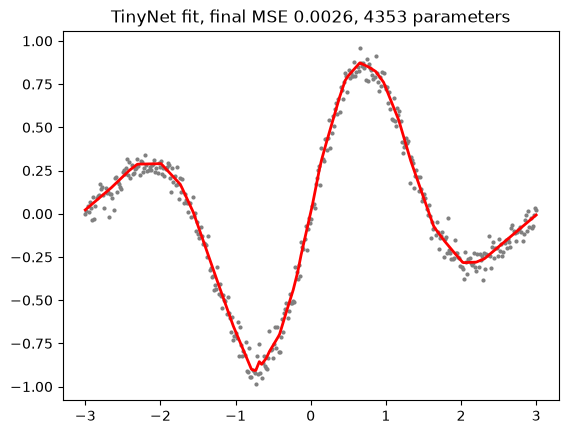

In [9]:
class TinyNet(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(n_in, n_hidden), nn.ReLU(), nn.Linear(n_hidden, n_hidden), nn.ReLU(), nn.Linear(n_hidden, n_out))
    def forward(self, x):
        return self.layers(x)

xs = torch.linspace(-3, 3, 400).unsqueeze(1); ys = torch.sin(2 * xs) * torch.exp(-xs ** 2 / 4) + 0.05 * torch.randn_like(xs)
net = TinyNet(1, 64, 1)
opt = torch.optim.Adam(net.parameters(), lr=1e-2)
for step in range(1500):
    opt.zero_grad(); loss = nn.functional.mse_loss(net(xs), ys); loss.backward(); opt.step()
with torch.no_grad():
    plt.scatter(xs, ys, s=4, c="grey"); plt.plot(xs, net(xs), "r", lw=2)
plt.title(f"TinyNet fit, final MSE {loss.item():.4f}, {sum(p_.numel() for p_ in net.parameters())} parameters"); plt.show()

# **Part 2: Going Deeper**

### Custom autograd functions
Define `forward` and `backward` ourselves, e.g. a **straight-through estimator** for a non-differentiable step (used for binarised networks and quantisation).

In [10]:
class StepSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        return (x > 0).float()
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output                      # pretend the step was the identity when going backwards

x_ste = torch.tensor([-1.0, 0.5, 2.0], requires_grad=True)
out = StepSTE.apply(x_ste).sum(); out.backward()
print("forward:", StepSTE.apply(x_ste).tolist(), "| gradient passed straight through:", x_ste.grad.tolist())

forward: [0.0, 1.0, 1.0] | gradient passed straight through: [1.0, 1.0, 1.0]


### Jacobians, Hessians and gradient checking with `torch.autograd`

In [11]:
from torch.autograd.functional import jacobian, hessian
f = lambda v: torch.stack([v[0] ** 2 * v[1], torch.sin(v[1])])
v0 = torch.tensor([1.0, 2.0])
print("Jacobian:\n", jacobian(f, v0))
g = lambda v: (v[0] - 1) ** 2 + 4 * (v[1] + 0.5) ** 2 + v[0] * v[1]
print("Hessian:\n", hessian(g, v0))
from torch.autograd import gradcheck
print("gradcheck of a double-precision sigmoid layer:", gradcheck(lambda t: torch.sigmoid(t @ t.T), (torch.randn(3, 3, dtype=torch.double, requires_grad=True),)))

Jacobian:
 tensor([[ 4.0000,  1.0000],
        [ 0.0000, -0.4161]])
Hessian:
 tensor([[2., 1.],
        [1., 8.]])
gradcheck of a double-precision sigmoid layer: True


## **Practice Problems**
1. Create a `(16, 4, 32, 32)` tensor and compute the per-channel standard deviation, then standardise each channel.
2. Use autograd to find the minimum of $f(x) = x^4 - 3x^3 + 2$ with plain gradient descent starting at x = 4.
3. Fit logistic regression on `make_moons` with `nn.Linear(2, 1)` and `nn.BCEWithLogitsLoss`. Report accuracy.
4. *(Advanced)* Compare PyTorch's gradient of the cross-entropy loss with respect to the logits with $p - y$ (Day 8).

In [12]:
# Solution 1
T = torch.randn(16, 4, 32, 32) * torch.tensor([1.0, 5.0, 0.1, 2.0]).view(1, 4, 1, 1)
sd = T.std(dim=(0, 2, 3), keepdim=True); Tn = (T - T.mean(dim=(0, 2, 3), keepdim=True)) / sd
print("per-channel std before:", sd.flatten().round(decimals=2).tolist(), "| after:", Tn.std(dim=(0, 2, 3)).round(decimals=2).tolist())
# Solution 2
xv = torch.tensor(4.0, requires_grad=True)
for _ in range(200):
    fx = xv ** 4 - 3 * xv ** 3 + 2; fx.backward()
    with torch.no_grad(): xv -= 0.01 * xv.grad
    xv.grad = None
print(f"minimum at x = {xv.item():.4f} (analytical 9/4 = 2.25)")
# Solution 3
from sklearn.datasets import make_moons
Xm, ym = make_moons(500, noise=0.2, random_state=0); Xm, ym = torch.tensor(Xm, dtype=torch.float32), torch.tensor(ym, dtype=torch.float32).unsqueeze(1)
clf = nn.Linear(2, 1); opt = torch.optim.Adam(clf.parameters(), lr=0.05)
for _ in range(500):
    opt.zero_grad(); l_ = nn.BCEWithLogitsLoss()(clf(Xm), ym); l_.backward(); opt.step()
print("logistic regression accuracy:", ((clf(Xm) > 0).float() == ym).float().mean().item())
# Solution 4
logits = torch.randn(5, 3, requires_grad=True); target = torch.tensor([0, 2, 1, 1, 0])
nn.functional.cross_entropy(logits, target, reduction="sum").backward()
p_y = torch.softmax(logits, 1).detach() - nn.functional.one_hot(target, 3)
print("autograd == p - y:", torch.allclose(logits.grad, p_y, atol=1e-6))

per-channel std before: [1.0, 4.989999771118164, 0.10000000149011612, 2.009999990463257] | after: [1.0, 1.0, 1.0, 1.0]
minimum at x = 2.2500 (analytical 9/4 = 2.25)


logistic regression accuracy: 0.8659999966621399
autograd == p - y: True


## **Key References**
- Paszke, A. et al. (2019). PyTorch: An imperative style, high-performance deep learning library. *NeurIPS 32*.
- Baydin, A. G., Pearlmutter, B. A., Radul, A. A., & Siskind, J. M. (2018). Automatic differentiation in machine learning: a survey. *JMLR*, 18(153), 1-43.
- Bengio, Y., Leonard, N., & Courville, A. (2013). Estimating or propagating gradients through stochastic neurons for conditional computation. arXiv:1308.3432 (straight-through estimator).
- Stevens, E., Antiga, L., & Viehmann, T. (2020). *Deep Learning with PyTorch*. Manning.